# Ramsey RF Gaussian velocity averaging

This notebook compares the mono-velocity Ramsey fringes at 184 m/s with
a Gaussian velocity average using mean 184 m/s and standard deviation
16 m/s. The average is computed with 7-point Gauss-Hermite quadrature.
All scans use CPU V3b with `K=24`, `basis_dt=10 us`, `dt_fine=0.05 us`.

In [ ]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make the local benchmarks/ package importable from the notebook's CWD.
_here = Path.cwd()
for _root in [_here, _here / "examples" / "ramsey_rf", _here.parent]:
    if (_root / "benchmarks" / "run_v3b_cpu_scans.py").exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        _BENCH_ROOT = _root
        break
else:
    raise RuntimeError("Could not locate examples/ramsey_rf/benchmarks/")

from benchmarks.reference import F_RES  # noqa: E402
from benchmarks.run_v3b_cpu_scans import (  # noqa: E402
    BASIS_DT_US_DEFAULT, FRINGE_HZ, K_DEFAULT,
    gaussian_velocity_nodes, run_frequency_scan,
)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})


In [ ]:
# Parameters — change here to alter what's computed.
K = K_DEFAULT                 # truncated subspace size (24)
BASIS_DT_US = BASIS_DT_US_DEFAULT  # adiabatic-tracking basis grid (10 us)
N_WORKERS = 8                 # process-pool workers per per-velocity scan

MEAN_VELOCITY = 184.0         # m/s, distribution mean
VELOCITY_STD = 16.0           # m/s, distribution std
N_VELOCITY_NODES = 7          # Gauss-Hermite nodes for the velocity average

N_FREQ = 161
FRINGES_WINDOW = 10.0         # +/- this many fringe spacings around F_RES

CACHE_DIR = _BENCH_ROOT / "benchmarks" / "_cache"
MONO_CACHE = CACHE_DIR / "v3b_far_frequency_scan_k24_basis10.npz"
VEL_CACHE = CACHE_DIR / "v3b_velocity_averaged_scan_k24_basis10.npz"

print(f"F_RES        = {F_RES * 1e-3:.3f} kHz")
print(f"fringe spacing = {FRINGE_HZ:.3f} Hz")
print(f"velocity dist  = {MEAN_VELOCITY} +/- {VELOCITY_STD} m/s, "
      f"{N_VELOCITY_NODES} Gauss-Hermite nodes")
print(f"caches:")
print(f"  mono baseline  = {MONO_CACHE.name}")
print(f"  velocity-avg   = {VEL_CACHE.name}")


In [ ]:
# Load-or-compute. The mono cache is shared with far_frequency_fringes.ipynb;
# the velocity-averaged cache holds per-velocity scans + the weighted average.
# Velocity scan cost: ~7 * (mono cost) ~ 60-90 min on 8 cores.

offsets = np.linspace(-FRINGES_WINDOW, FRINGES_WINDOW, N_FREQ)
freqs = F_RES + offsets * FRINGE_HZ

# --- mono baseline (184 m/s) ---
if MONO_CACHE.exists():
    print(f"Loading mono cache: {MONO_CACHE.name}")
    mono_data = dict(np.load(MONO_CACHE))
else:
    print(f"Computing mono baseline ({N_FREQ} points)...")
    mono_survival, mono_elapsed_s, mono_n_steps = run_frequency_scan(
        freqs, velocity=MEAN_VELOCITY, K=K, basis_dt_us=BASIS_DT_US, n_workers=N_WORKERS,
    )
    mono_data = {
        "freqs": freqs, "offsets": offsets, "survival": mono_survival,
        "mean_velocity": np.float64(MEAN_VELOCITY), "velocity": np.float64(MEAN_VELOCITY),
        "fringe_hz": np.float64(FRINGE_HZ), "K": np.int64(K),
        "basis_dt_us": np.float64(BASIS_DT_US), "n_workers": np.int64(N_WORKERS),
        "n_steps": np.int64(mono_n_steps), "elapsed_s": np.float64(mono_elapsed_s),
    }
    MONO_CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez(MONO_CACHE, **mono_data)
    print(f"  done in {mono_elapsed_s / 60:.2f} min, saved {MONO_CACHE.name}")

# --- velocity-averaged scan (7 nodes) ---
if VEL_CACHE.exists():
    print(f"Loading velocity cache: {VEL_CACHE.name}")
    vel_data = dict(np.load(VEL_CACHE))
else:
    print(f"Computing velocity-averaged scan: "
          f"{N_VELOCITY_NODES} velocities x {N_FREQ} freqs "
          f"~ {N_VELOCITY_NODES * N_FREQ * 7 / 60 / N_WORKERS:.0f} min on {N_WORKERS} cores...")
    velocities, weights = gaussian_velocity_nodes(MEAN_VELOCITY, VELOCITY_STD, N_VELOCITY_NODES)
    survival_by_velocity = np.empty((velocities.size, freqs.size), dtype=np.float64)
    elapsed_by_velocity = np.empty(velocities.size, dtype=np.float64)
    n_steps_by_velocity = np.empty(velocities.size, dtype=np.int64)
    for idx, v in enumerate(velocities):
        print(f"  velocity {idx + 1}/{velocities.size}: v={v:.3f} m/s, weight={weights[idx]:.4f}")
        s, el, ns = run_frequency_scan(
            freqs, velocity=float(v), K=K, basis_dt_us=BASIS_DT_US, n_workers=N_WORKERS,
        )
        survival_by_velocity[idx] = s
        elapsed_by_velocity[idx] = el
        n_steps_by_velocity[idx] = ns
        print(f"    {el / 60:.2f} min, "
              f"survival range=({s.min():.4f}, {s.max():.4f})")
    averaged = weights @ survival_by_velocity
    vel_data = {
        "freqs": freqs, "offsets": offsets,
        "velocities": velocities, "weights": weights,
        "survival_by_velocity": survival_by_velocity,
        "survival_velocity_averaged": averaged,
        "mean_velocity": np.float64(MEAN_VELOCITY),
        "velocity_std": np.float64(VELOCITY_STD),
        "fringe_hz": np.float64(FRINGE_HZ),
        "K": np.int64(K), "basis_dt_us": np.float64(BASIS_DT_US),
        "n_workers": np.int64(N_WORKERS),
        "n_velocity_nodes": np.int64(velocities.size),
        "n_steps_by_velocity": n_steps_by_velocity,
        "elapsed_by_velocity_s": elapsed_by_velocity,
        "elapsed_total_s": np.float64(np.sum(elapsed_by_velocity)),
    }
    VEL_CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez(VEL_CACHE, **vel_data)
    print(f"  total {np.sum(elapsed_by_velocity) / 60:.2f} min, saved {VEL_CACHE.name}")


In [ ]:
# Extract arrays from the loaded/computed dicts.
freqs = vel_data["freqs"]
offsets = vel_data["offsets"]
fringe_hz = float(vel_data["fringe_hz"])
detuning_hz = offsets * fringe_hz
velocities = vel_data["velocities"]
weights = vel_data["weights"]
survival_by_velocity = vel_data["survival_by_velocity"]
survival_avg = vel_data["survival_velocity_averaged"]

mono_survival = mono_data["survival"]
mono_excitation = 1.0 - mono_survival
avg_excitation = 1.0 - survival_avg

summary = {
    "frequency_points": len(freqs),
    "velocity_nodes": len(velocities),
    "velocity_mean_m_s": float(vel_data["mean_velocity"]),
    "velocity_std_m_s": float(vel_data["velocity_std"]),
    "elapsed_total_min": float(vel_data["elapsed_total_s"]) / 60.0,
    "mono_contrast": float(mono_survival.max() - mono_survival.min()),
    "averaged_contrast": float(survival_avg.max() - survival_avg.min()),
    "max_abs_survival_change": float(np.max(np.abs(survival_avg - mono_survival))),
}
summary


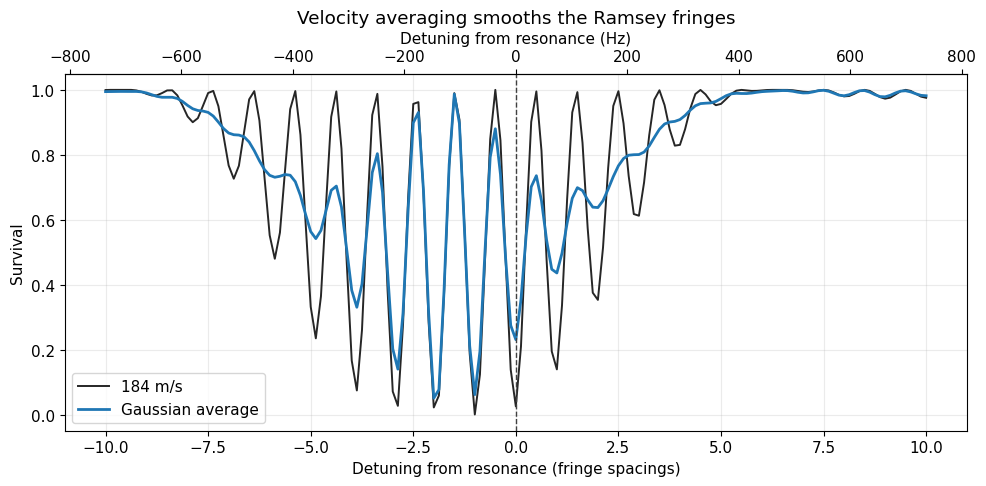

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(offsets, mono_survival, color="0.15", lw=1.4, label="184 m/s")
ax.plot(offsets, survival_avg, color="tab:blue", lw=2.0, label="Gaussian average")
ax.axvline(0, color="0.25", lw=1, ls="--")
ax.set_xlabel("Detuning from resonance (fringe spacings)")
ax.set_ylabel("Survival")
ax.set_title("Velocity averaging smooths the Ramsey fringes")
ax.legend()

top = ax.secondary_xaxis(
    "top",
    functions=(lambda x: x * fringe_hz, lambda x: x / fringe_hz),
)
top.set_xlabel("Detuning from resonance (Hz)")
fig.tight_layout()

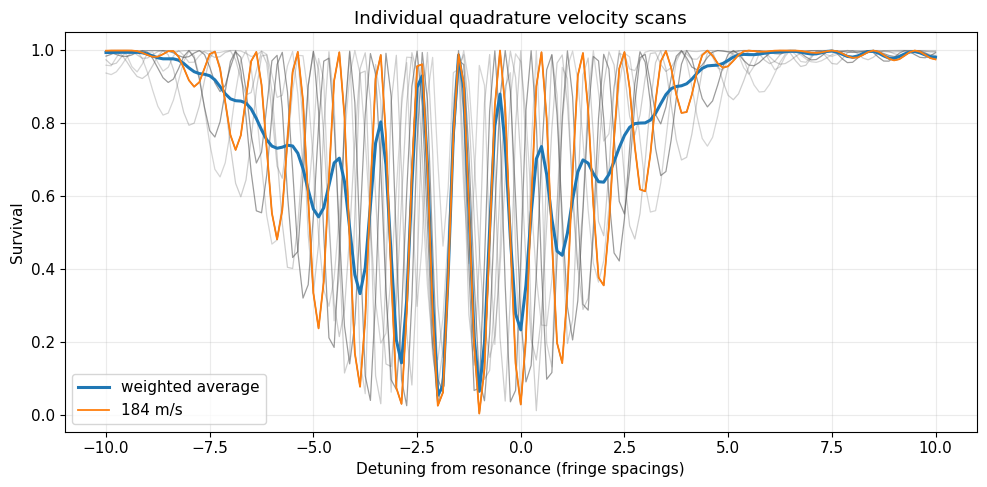

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for v, w, survival in zip(velocities, weights, survival_by_velocity):
    alpha = 0.25 + 0.65 * (w / weights.max())
    ax.plot(offsets, survival, color="0.35", alpha=alpha, lw=0.9)
ax.plot(offsets, survival_avg, color="tab:blue", lw=2.2, label="weighted average")
ax.plot(offsets, mono_survival, color="tab:orange", lw=1.3, label="184 m/s")
ax.set_xlabel("Detuning from resonance (fringe spacings)")
ax.set_ylabel("Survival")
ax.set_title("Individual quadrature velocity scans")
ax.legend()
fig.tight_layout()

Velocity nodes and weights:
   123.993 m/s   weight=0.000548   scan=18.90 min
   146.132 m/s   weight=0.030757   scan=16.11 min
   165.530 m/s   weight=0.240123   scan=14.17 min
   184.000 m/s   weight=0.457143   scan=12.77 min
   202.470 m/s   weight=0.240123   scan=11.61 min
   221.868 m/s   weight=0.030757   scan=10.56 min
   244.007 m/s   weight=0.000548   scan=9.67 min


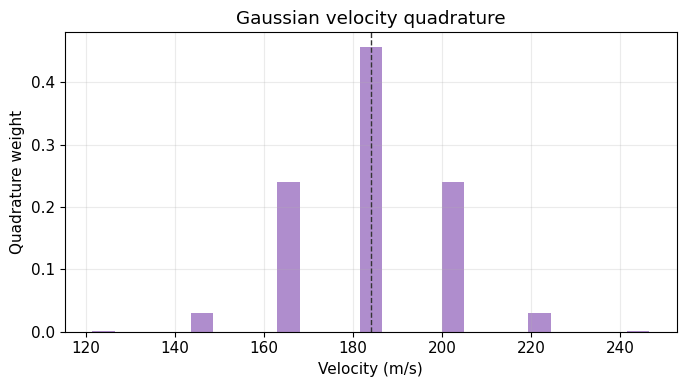

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(velocities, weights, width=5.0, color="tab:purple", alpha=0.75)
ax.axvline(float(vel_data["mean_velocity"]), color="0.2", lw=1, ls="--")
ax.set_xlabel("Velocity (m/s)")
ax.set_ylabel("Quadrature weight")
ax.set_title("Gaussian velocity quadrature")
fig.tight_layout()

print("Velocity nodes and weights:")
for v, w, elapsed in zip(velocities, weights, vel_data["elapsed_by_velocity_s"]):
    print(f"  {v:8.3f} m/s   weight={w:.6f}   scan={elapsed / 60:.2f} min")

The averaged curve is not just a vertical rescaling: each velocity has a
different time of flight through the RF regions, so the fringe phase and
envelope shift before the weighted average is taken.